In [1]:
import pandas as pd

In [2]:
dataframe = pd.read_csv("local-data/wandb_samples/wandb_export_2026-04-19T17_00_54.100+02_00.csv")

In [4]:
dataframe.head()

,Step,lux_v2_mappo_seq - collection/reward/reward_mean,lux_v2_mappo_seq - collection/reward/reward_mean__MIN,lux_v2_mappo_seq - collection/reward/reward_mean__MAX
0,0,0.070182,0.070182,0.070182
1,1,0.060808,0.060808,0.060808
2,2,0.056610,0.056610,0.056610
3,3,0.042615,0.042615,0.042615
4,4,0.068726,0.068726,0.068726


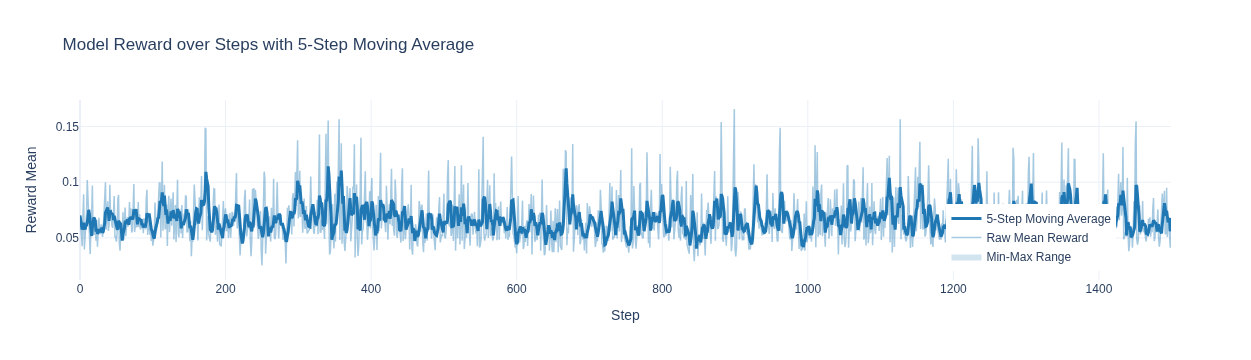

In [6]:
import pandas as pd
import plotly.graph_objects as go

# Assuming your dataframe is named `df`, for example:
# df = pd.read_csv('your_metrics.csv')

# Column names based on your provided dataframe
col_step = "Step"
col_mean = "lux_v2_mappo_seq - collection/reward/reward_mean"
col_min = "lux_v2_mappo_seq - collection/reward/reward_mean__MIN"
col_max = "lux_v2_mappo_seq - collection/reward/reward_mean__MAX"

# 计算 5-step 移动平均 (calculate 5-step rolling moving average)
# We use min_periods=1 so that the first 4 steps don't become NaN values
df = dataframe
df['moving_avg_5'] = df[col_mean].rolling(window=5, min_periods=1).mean()

# Initialize the plotly figure
fig = go.Figure()

# 1. Add MAX line (invisible boundary for the shaded fill)
fig.add_trace(go.Scatter(
    x=df[col_step],
    y=df[col_max],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))

# 2. Add MIN line (fills down to the MAX line above it to create the band)
fig.add_trace(go.Scatter(
    x=df[col_step],
    y=df[col_min],
    mode='lines',
    line=dict(width=0),
    fill='tonexty',
    fillcolor='rgba(31, 119, 180, 0.2)', # semi-transparent blue band
    name='Min-Max Range'
))

# 3. Add the raw mean line (plotted with lower opacity so it doesn't distract from the moving average)
fig.add_trace(go.Scatter(
    x=df[col_step],
    y=df[col_mean],
    mode='lines',
    line=dict(color='rgba(31, 119, 180, 0.4)', width=1.5),
    name='Raw Mean Reward'
))

# 4. Add the 5-step moving average line (main solid line)
fig.add_trace(go.Scatter(
    x=df[col_step],
    y=df['moving_avg_5'],
    mode='lines',
    line=dict(color='rgba(31, 119, 180, 1.0)', width=3),
    name='5-Step Moving Average'
))

# Update layout to make it look professional
fig.update_layout(
    title='Model Reward over Steps with 5-Step Moving Average',
    xaxis_title='Step',
    yaxis_title='Reward Mean',
    template='plotly_white',
    hovermode='x unified', # Shows all trace values when hovering over a specific x-axis point
    legend=dict(
        yanchor="bottom",
        y=0.05,
        xanchor="right",
        x=0.95
    )
)

# Display the interactive plot
fig.show()
